# Is there a relationship between gender and preferred steak preparation, and how do steak doneness preferences compare between males and females?


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
sns.set_theme(style="whitegrid")

In [5]:
df = pd.read_csv("steak.csv")
df = df.iloc[1:].copy()

In [6]:
col_steak = 'How do you like your steak prepared?'
col_gender = 'Gender'
df_clean = df.dropna(subset=[col_steak, col_gender]).copy()

In [7]:
steak_order = ["Rare", "Medium rare", "Medium", "Medium Well", "Well"]
df_clean[col_steak] = pd.Categorical(df_clean[col_steak], categories=steak_order)

In [8]:
rel_pct = (pd.crosstab(df_clean[col_steak], df_clean[col_gender], normalize="columns") * 100).round(1)

In [9]:
rel_long = (
    rel_pct
    .reset_index()
    .melt(id_vars=col_steak, var_name="Gender", value_name="percent")
)


In [10]:
print("--- RELATIVE FREQUENCY (%) ---")
print(rel_pct)

--- RELATIVE FREQUENCY (%) ---
Gender                                Female  Male
How do you like your steak prepared?              
Rare                                     6.0   4.7
Medium rare                             38.5  38.2
Medium                                  26.5  34.9
Medium Well                             18.5  15.6
Well                                    10.5   6.6


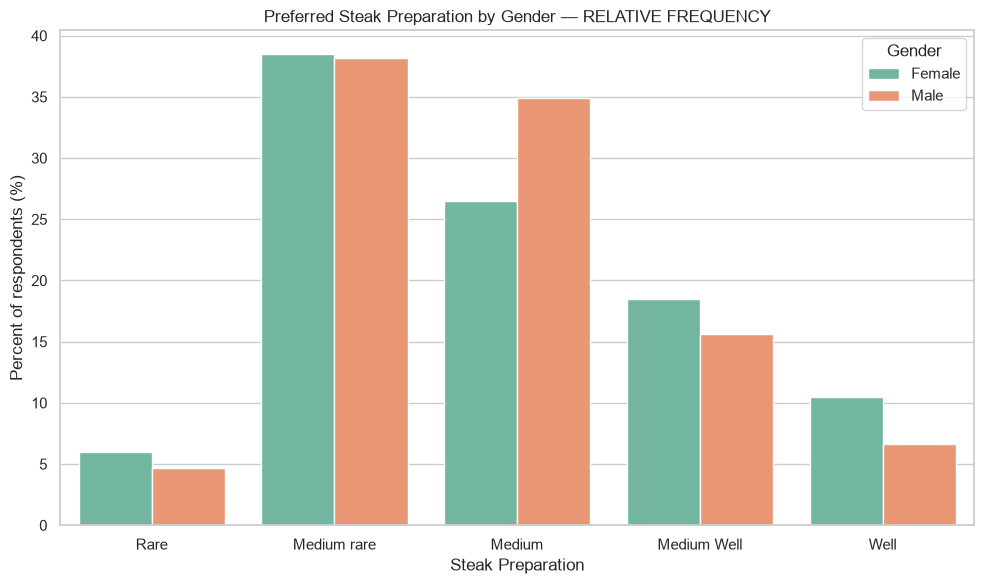

In [11]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=rel_long, x=col_steak, y="percent",
    hue="Gender", order=steak_order,
    hue_order=["Female", "Male"],
    palette="Set2"
)
ax.set_title("Preferred Steak Preparation by Gender — RELATIVE FREQUENCY")
ax.set_xlabel("Steak Preparation")
ax.set_ylabel("Percent of respondents (%)")
ax.legend(title="Gender")
plt.tight_layout()

## Conclusion
### Both men and women prefer "Medium rare" steak the most, making it the top choice across both groups. However, men are more likely to choose "Medium," while women tend to favor steaks cooked longer, such as "Medium Well" and "Well" done